In [1]:
!pip uninstall odc-stac -y --quiet
!pip install odc-stac --quiet
!pip uninstall pystac-client -y --quiet
!pip install pystac-client --quiet
!pip install -U pystac --quiet

In [2]:
!pip uninstall dea-tools -y --quiet
!pip install dea-tools==0.4.4 --quiet

# Simple Urban Classifier using only SAR 


## Description
1. Load and pre-process Sentinel-1 SAR data
2. Load training data for urban classification from Global Urban Footprint Urban Fraction in the NCI 
3. Train Random Forest Classifier and see results

***

## Getting started

### Load packages
Import Python packages that are used for the analysis.

Use standard import commands; some are shown below. 
Begin with any `iPython` magic commands, followed by standard Python packages, then any additional functionality you need from the `Tools` directory.

In [3]:
%matplotlib inline

import odc.geo.xr
import datacube
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from dea_tools.datahandling import load_ard
from dea_tools.plotting import rgb
from dea_tools.validation import xr_random_sampling
from dea_tools.classification import collect_training_data
from dea_tools.dask import create_local_dask_cluster

from odc.geo import BoundingBox
from pystac_client import Client
from odc.geo.xr import assign_crs


In [4]:
#client = create_local_dask_cluster(return_client=True) # dask is giving issue with smart filter, quick solution is not using dask for now

### Environment set up

In [5]:
dc = datacube.Datacube(app="S1")

## View available collections

In [6]:
dc_measurements = dc.list_measurements()
dc_measurements.loc['ga_s1_nrb_iw_vv_vh_0']

,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
VV_gamma0,VV_gamma0,float32,linear power,NaN,[vv_gamma0],NaN
VH_gamma0,VH_gamma0,float32,linear power,NaN,[vh_gamma0],NaN
mask,mask,uint8,classification,255,NaN,"{'mask': {'bits': [0, 1, 2, 3, 4, 5, 6, 7], 'v..."
number_of_looks,number_of_looks,float32,count,NaN,"[n_looks, nlooks]",NaN
gamma0_to_beta0_ratio,gamma0_to_beta0_ratio,float32,ratio,NaN,NaN,NaN
gamma0_to_sigma0_ratio,gamma0_to_sigma0_ratio,float32,ratio,NaN,NaN,NaN
local_incidence_angle,local_incidence_angle,float32,degrees,NaN,"[lia, LIA]",NaN
incidence_angle,incidence_angle,float32,degrees,NaN,"[ia, IA]",NaN


## View collection metadata

Displaying the result from `get_collection()` will provide an expandable JSON output showing the collection-level metadata. 

In [7]:
dc.index.products.get_by_name("ga_s1_nrb_iw_hh_c0").fields

{'creation_time': None,
 'format': None,
 'label': None,
 'lat': None,
 'lon': None,
 'time': None,
 'beam_id': None,
 'crs_raw': None,
 'burst_id': None,
 'platform': None,
 'scene_id': None,
 'source_id': None,
 'instrument': None,
 'orbit_file': None,
 'orbit_cycle': None,
 'orbit_state': None,
 'region_code': None,
 'orbit_source': None,
 'conversion_eq': None,
 'absolute_orbit': None,
 'product_family': 'sar_ard',
 'relative_orbit': None,
 'dataset_version': None,
 'instrument_mode': None,
 'measurement_type': None,
 'noise_removal_applied': None,
 'observation_direction': None,
 'measurement_convention': None,
 'speckle_filter_applied': None,
 'far_range_incidence_angle': None,
 'near_range_incidence_angle': None,
 'bistatic_correction_applied': None,
 'ionospheric_correction_applied': None,
 'wet_tropospheric_correction_applied': None,
 'static_tropospheric_correction_applied': None}

## Set search parameters

These are primarily used by the search step, but may also be re-used in load

In [22]:
# Set random seed for reproducibility
rand_state = 42

# Products to query
product_to_load = "ga_s1_nrb_iw_vv_vh_0"

# Area of interest
aoi_bbox = BoundingBox(
    left=149.80,
    bottom=-34.01,
    right= 151.0,
    top=-33.85,
    crs="EPSG:4326"
)

# Date range of interest
start_date = "2024-07-01"
end_date = "2025-06-30"

# Measurements to load
measurements_to_load = ["VV_gamma0", "VH_gamma0", "mask","number_of_looks"]

# CRS and resolution
output_crs = "EPSG:3577"
output_res = 20 

# Property or function to group by. "solar_day" is already built into odc-stac
groupy_by_operation = "solar_day"

# Display the Area of Interest on a map
aoi_bbox.explore()

## Run load

Note that the load function takes:
* `items`: a pystac-client items_collection
* `bands`: a list of assets to load
* `intersects`: a geometry to intersect
* `crs`: a coordinate reference system for the output
* `resolution`: a resolution for the output
* `groupby`: a method or property to group by
* `chunks`: (optionally) a dictionary describing how to chunk the data for lazy loading (recommended)


In [23]:
# ds = dc.load(
#     product=product_to_load,
#     measurements=measurements_to_load,
#     lat=(aoi_bbox.bottom, aoi_bbox.top),
#     lon=(aoi_bbox.left, aoi_bbox.right),
#     output_crs=output_crs,
#     resolution=(output_res, -output_res),
#     time=(start_date, end_date),
#     group_by=groupy_by_operation,
#     dask_chunks={},
#     skip_broken_datasets=True
# )

In [24]:
# if not using dask, use this to monitor load speed

def month_ranges(start_date, end_date):
    start = pd.to_datetime(start_date).replace(day=1)
    end = pd.to_datetime(end_date)
    current = start
    while current <= end:
        next_month = (current + pd.DateOffset(months=1)).replace(day=1)
        # last day of the current month is one day before next_month
        last_day_current_month = next_month - pd.Timedelta(days=1)
        chunk_end = min(last_day_current_month, end)
        yield current, chunk_end
        current = next_month
        
datasets = []
ranges = list(month_ranges(start_date, end_date))

for i, (t_start, t_end) in enumerate(ranges):
    print(f"Loading chunk {i+1} / {len(ranges)}: {t_start.strftime('%Y-%m-%d')} to {t_end.strftime('%Y-%m-%d')}", end='\r')
    ds_chunk = dc.load(
        product=product_to_load,
        measurements=measurements_to_load,
        lat=(aoi_bbox.bottom, aoi_bbox.top),
        lon=(aoi_bbox.left, aoi_bbox.right),
        output_crs=output_crs,
        resolution=(output_res, -output_res),
        time=(t_start, t_end),
        group_by=groupy_by_operation,
        skip_broken_datasets=True
    )
    datasets.append(ds_chunk)

ds = xr.concat(datasets, dim='time')


In [25]:
ds

<xarray.Dataset> Size: 14GB
Dimensions:          (time: 114, y: 1676, x: 5590)
Coordinates:
  * time             (time) datetime64[ns] 912B 2024-07-01T19:08:04.991087 .....
  * y                (y) float64 13kB -3.841e+06 -3.841e+06 ... -3.808e+06
  * x                (x) float64 45kB 1.742e+06 1.742e+06 ... 1.63e+06 1.63e+06
    spatial_ref      int32 4B 3577
Data variables:
    VV_gamma0        (time, y, x) float32 4GB 0.1188 0.09246 0.1216 ... nan nan
    VH_gamma0        (time, y, x) float32 4GB 0.03352 0.04234 ... nan nan
    mask             (time, y, x) uint8 1GB 0 0 0 0 0 0 ... 255 255 255 255 255
    number_of_looks  (time, y, x) float32 4GB 8.906 8.895 8.999 ... nan nan nan
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

## Process the data

* Speckle filter

We will apply the new smart speckle filter developed during the S1-hackathon
https://github.com/cbur24/sentinel-1-hackathon/blob/speckle_filters/src/lee_sigma_improved_xr.py

* Masking

The GA Sentinel-1 backscatter product comes with a mask that indicates invalid pixels, along with pixels impacted by layover and shadow. 

The masks have the following values:
| Value | Property |
| --- | ----------- |
| 0 | Valid | 
| 1 | Shadow |
| 2 | Layover |
| 3 | Shadow and layover |
| 255 / NaN | Invalid |

The following code displays the masks and shows how to apply them.

* Generate summary statistics


In [26]:
# load smart speckle filter 
# load function from the script on the other branch
import requests
url = "https://raw.githubusercontent.com/cbur24/sentinel-1-hackathon/refs/heads/speckle_filters/src/lee_sigma_improved_xr.py"
code = requests.get(url).text
exec(code)
# now we can use lee_sigma_improved_xr()

In [28]:
# standard filter
url_std = 'https://raw.githubusercontent.com/cbur24/sentinel-1-hackathon/refs/heads/speckle_filters/src/speckle_filters.py'
code_std = requests.get(url_std).text
exec(code_std)

In [29]:
def apply_lee_sigma_cube(img, **kwargs): # currently lee_sigma_improved_xr uses only first time step
    return xr.concat(
        [lee_sigma_improved_xr(img.isel(time=i), **kwargs).expand_dims(time=[img.time.values[i]])
         for i in range(img.sizes["time"])],
        dim="time"
    )
    
def process_cube(ds, speckle_filter):

    if speckle_filter == 'standard':
        ds["VV_gamma0_filtered"] = apply_lee_filter(ds["VV_gamma0"], size=3)
        ds["VH_gamma0_filtered"] = apply_lee_filter(ds["VH_gamma0"], size=3)

    if speckle_filter == 'smart': 
        ds["VV_gamma0_filtered"] = apply_lee_sigma_cube(ds, band_name='VV_gamma0', nlooks='number_of_looks', data_type='intensity')
        ds["VH_gamma0_filtered"] = apply_lee_sigma_cube(ds, band_name='VH_gamma0', nlooks='number_of_looks', data_type='intensity')

    ds["VV_gamma0_masked"] = xr.where(ds.mask == 0, ds["VV_gamma0_filtered"], np.nan)
    ds["VH_gamma0_masked"] = xr.where(ds.mask == 0, ds["VH_gamma0_filtered"], np.nan)

    ds_reduced = ds.drop_vars([
        'VV_gamma0', 'VH_gamma0', 'mask','number_of_looks',
        'VV_gamma0_filtered', 'VH_gamma0_filtered'
    ])

    ds_grouped = ds_reduced.groupby('time.month')
    ds_final = ds_grouped.mean().drop_vars(['VV_gamma0_masked', 'VH_gamma0_masked'])

    ds_final['mean_vv'] = ds_grouped.mean()['VV_gamma0_masked']
    ds_final['mean_vh'] = ds_grouped.mean()['VH_gamma0_masked']
    ds_final['max_vv'] = ds_grouped.max()['VV_gamma0_masked']
    ds_final['max_vh'] = ds_grouped.max()['VH_gamma0_masked']
    ds_final['min_vv'] = ds_grouped.min()['VV_gamma0_masked']
    ds_final['min_vh'] = ds_grouped.min()['VH_gamma0_masked']
    ds_final['std_vv'] = ds_grouped.std()['VV_gamma0_masked']
    ds_final['std_vh'] = ds_grouped.std()['VH_gamma0_masked']

    return ds_final


In [ ]:
ds_final = process_cube(ds, speckle_filter='smart')

In [ ]:
ds_final

In [ ]:
#ds_final = ds_final.compute()

In [ ]:
ds_final.to_netcdf('ds_final.nc')

## Open and pre-process training data file

In [ ]:
urban_GUF = xr.open_dataarray('https://thredds.nci.org.au/thredds/dodsC/ub8/au/LandCover/OzWALD_LC/GUF_FractionUrban_Australia.nc')
urban_GUF = urban_GUF.transpose('latitude', 'longitude')
urban_GUF = assign_crs(urban_GUF, crs='EPSG:4326')

In [ ]:
urban_GUF_box = urban_GUF.odc.reproject(how=ds.odc.geobox, resampling='bilinear')
urban = xr.where(urban_GUF_box>70, 1, 0) # consider urban when more than 70% confidence
urban = assign_crs(urban.astype('int16'), crs='EPSG:3577')

In [ ]:
# xr_random_sampling() uses random choice from numpy, so we will set the seed for numpy random operations 
np.random.seed(rand_state)
train_points = xr_random_sampling(urban, sampling='manual', manual_class_ratios={'1':500, '0':500})

In [ ]:
train_points['class'] = train_points['class'].astype(int)

In [ ]:
train_points.plot(column='class', markersize=.1)

## Create dataframe to train model

In [ ]:
cols = ['urban'] + [f'{stat}_{band}_{month}' for stat in ['mean','max','min','std'] for band in ['vv', 'vh'] for month in range(1,13)]
#cols = ['urban'] + [f'{stat}_{band}_{month}' for stat in ['mean','std'] for band in ['vv', 'vh'] for month in range(1,13)]

train_df = pd.DataFrame(columns=cols, index=range(len(train_points)))

In [ ]:
for i, (c, g) in enumerate(zip(train_points['class'], train_points.geometry)):
    print(i, end='\r')
    ds_point = ds_final.sel(x=g.x, y=g.y, method="nearest")

    # assign response variable (row i, first column, i.e. column index 0)
    train_df.loc[i,'urban'] = c
    
    for col in train_df.columns[1:]:
        var = '_'.join(col.split('_')[:-1])
        month = int(col.split('_')[-1])

        train_df.loc[i, col] = ds_point.sel( month=month)[var].data

In [ ]:
train_df.to_csv('samples_df_updated.csv',index=False)

## Split train/test

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

In [ ]:
# apply stratified sampling
strat_split = StratifiedShuffleSplit(n_splits=1, test_size=.2, random_state=rand_state)
for train_index, test_index in strat_split.split(train_df, train_df['urban']):
    train_final = train_df.loc[train_index].copy() 
    test_final = train_df.loc[test_index].copy() 

In [ ]:
predictors = cols[1:]
print(', '.join(predictors))

In [ ]:
# define response and explanatory vars train_final dataset
resp_train = train_final['urban'].astype(int).copy() 
expl_train = train_final[predictors].copy()

# define response and explanatory for test_final dataset
resp_test = test_final['urban'].astype(int).copy() 
expl_test = test_final[predictors].copy()

print(f'Train count: {len(resp_train.index)}')
print(f'Test count: {len(resp_test.index)}')

## Random forest classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, GridSearchCV
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint

In [ ]:
rf = RandomForestClassifier(n_jobs=-1, random_state=rand_state)

In [ ]:
# ranges of possible hyperparameters
hyperpar = {'n_estimators': randint(low=10,high=150),  
            'criterion': ['gini','entropy','log_loss'], 
            'max_depth': randint(low=5,high=30), 
            'min_samples_split': randint(low=2,high=30), 
            'min_samples_leaf': randint(low=1,high=20),
            'max_features': randint(low=1,high=len(predictors)), 
            'bootstrap': [True, False],
            }

In [ ]:
from sklearn.metrics import make_scorer, precision_score

rf_rand_search = RandomizedSearchCV(
    rf, 
    param_distributions=hyperpar, 
    n_iter=200, # try 200 hyperparameters combos
    scoring='f1', 
    cv=4, 
    verbose= 1, 
    n_jobs=-1,
    random_state=rand_state
)
                                    
rf_rand_search.fit(expl_train, resp_train)

In [ ]:
# best model and score of best model
rf_rand_search.best_params_, rf_rand_search.best_score_

In [ ]:
hyperparameters = ['n_estimators','max_depth','min_samples_split','min_samples_leaf','max_features'] 

for hyperparam_name in hyperparameters:
    
    hyperparam_values = rf_rand_search.cv_results_['param_' + hyperparam_name] 
    mean_scores = rf_rand_search.cv_results_['mean_test_score']
    
    # extract all scores for each hyperparameter value 
    hyperparam_tot_scores = dict()
    for value, score in zip(hyperparam_values, mean_scores):
        if value not in hyperparam_tot_scores: 
            hyperparam_tot_scores[value] = [score]
        else:
            hyperparam_tot_scores[value].append(score) 
    
    # mean scores for each hyperparameter value
    sorted_hyperparams = sorted(hyperparam_tot_scores.keys())
    averaged_scores = [np.nanmean(hyperparam_tot_scores[val]) for val in sorted_hyperparams]

    plt.figure(figsize=(20, 6))
    plt.plot(sorted_hyperparams, averaged_scores, marker='o', linestyle='-')

    plt.xlim([min(sorted_hyperparams), max(sorted_hyperparams)])
    plt.ylabel('Mean Score')
    plt.title(f'{hyperparam_name}')
    plt.grid(True)

    plt.show()

In [87]:
hyperpar = {
    'n_estimators': [20,40],  
    'criterion': ['entropy'],  
    'max_depth': [9], 
    'min_samples_split': [13,14],  
    'min_samples_leaf':[4,6,9],  
    'max_features': [11,12,13],
    'bootstrap': [True], 
}

# search all combinations of above values
rf_grid_search = GridSearchCV(rf, 
                              param_grid=hyperpar, 
                              scoring='f1', 
                              cv=4, 
                              verbose=1, 
                              n_jobs=-1)

rf_grid_search.fit(expl_train, resp_train)

Fitting 4 folds for each of 36 candidates, totalling 144 fits


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'bootstrap': [True], 'criterion': ['entropy'],
                         'max_depth': [9], 'max_features': [11, 12, 13],
                         'min_samples_leaf': [4, 6, 9],
                         'min_samples_split': [13, 14],
                         'n_estimators': [20, 40]},
             scoring='f1', verbose=1)

In [88]:
rf_grid_search.best_params_, rf_grid_search.best_score_ 

({'bootstrap': True,
  'criterion': 'entropy',
  'max_depth': 9,
  'max_features': 11,
  'min_samples_leaf': 4,
  'min_samples_split': 13,
  'n_estimators': 20},
 0.7919114648994316)

In [89]:
# best model
rf_best = rf_grid_search.best_estimator_

In [90]:
# save best model
from joblib import dump
dump(rf_best, f'RF_urban_classifier_updated.joblib')

['RF_urban_classifier_updated.joblib']

### Feature importance

In [ ]:
feat_importances = rf_best.feature_importances_
rf_importance = zip(predictors, feat_importances)
    
plt.figure(figsize=(15, 15))
plt.barh(predictors, feat_importances)
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.show()

## Model performance 

### Same area of training data

In [92]:
# define functions to generate 2D arrays of estimated urban area

def flatten_months(ds):
    months = ds['month'].values

    new_vars = {}
    for var in ds.data_vars:
        for i in range(ds.sizes['month']):
            mlabel = months[i]
            label = f"{int(mlabel)}"
            
            da = ds[var].isel(month=i)

            da = da.reset_coords('month', drop=True)

            new_vars[f"{var}_{label}"] = da

    return xr.Dataset(new_vars)



def get_estimated_urban_array(ds, predictors, model, ds_already_preprocessed=False, speckle_filter='standard'):

    ds_final = ds
    
    if ds_already_preprocessed == False:
        ds_final = process_cube(ds, speckle_filter)
        ds_final = ds_final.compute()

    ds_final = flatten_months(ds_final)

    ds_final = ds_final.sortby('x')  # west to east
    ds_final = ds_final.sortby('y', ascending=False)  # north to south

    input_array = ds_final[predictors].to_array().values
    nan_mask = np.isnan(input_array)
    nan_mask_2d = np.sum(np.where(nan_mask, 1, 0), axis=0)
    input_array = np.where(nan_mask, 0, input_array) # replace NaN with zeros to run model without issues

    n_vars, y_size, x_size = input_array.shape
    input_rf = input_array.reshape((n_vars, -1)).swapaxes(0, 1)

    predicted_urban = model.predict(input_rf)
    predicted_urban_2d = predicted_urban.reshape((y_size, x_size))
    predicted_urban_2d = np.where(nan_mask_2d > 0, np.nan, predicted_urban_2d) # put back NaNs, if there were any

    # format array as datarray with coords and georeferenced
    out_da = xr.DataArray(
        predicted_urban_2d,
        dims=('y', 'x'),
        coords={'y': ds_final['y'].values, 'x': ds_final['x'].values},
        name='predicted_urban'
    )
    crs = ds_final.odc.crs
    out_da = assign_crs(out_da, crs)

    return out_da


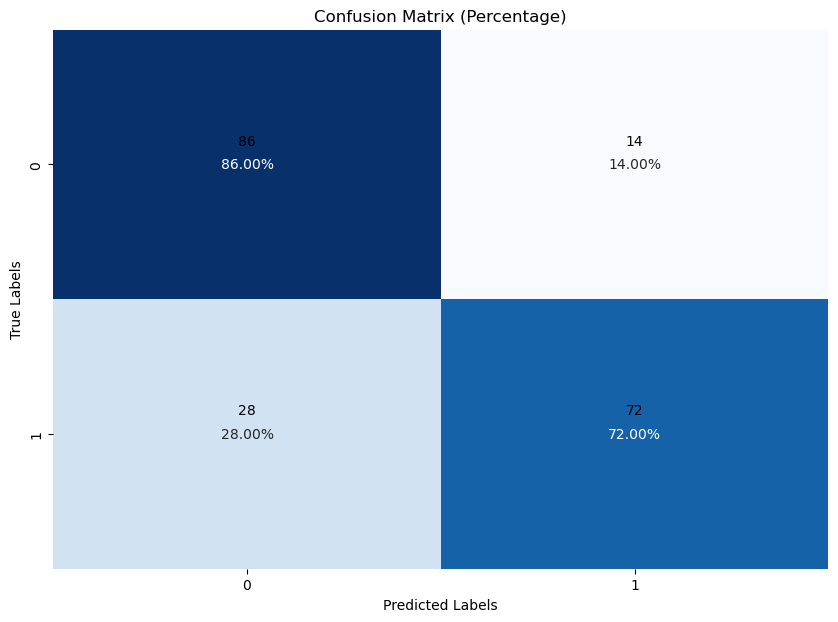

Accuracy: 0.7900
Weighted F1 Score: 0.7890
Weighted Precision: 0.7958
Weighted Recall: 0.7900


In [93]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, f1_score, precision_score, recall_score, classification_report, average_precision_score
import seaborn as sns 

# true labels and predictions
y_true = resp_test
y_pred = rf_best.predict(expl_test[predictors])

cm = confusion_matrix(y_true, y_pred)

# show percentages (recall)
cm_normalised = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cm_normalised, annot=True, fmt='.2%', cmap='Blues', cbar=False, ax=ax)
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
ax.set_title('Confusion Matrix (Percentage)')

# add counts in the cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j+0.5, i+0.5, f'{cm[i, j]}\n', 
                ha='center', va='bottom', color='black')

plt.show()

# metrics
accuracy = accuracy_score(y_true, y_pred)
f1_weighted = f1_score(y_true, y_pred, average='weighted')
precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.4f}')
print(f'Weighted F1 Score: {f1_weighted:.4f}')
print(f'Weighted Precision: {precision_weighted:.4f}')
print(f'Weighted Recall: {recall_weighted:.4f}')

In [94]:
# classification summary 
report = classification_report(y_true, y_pred, output_dict=True)

report_df = pd.DataFrame(report).transpose()

print(report_df)

              precision  recall  f1-score  support
0              0.754386    0.86  0.803738   100.00
1              0.837209    0.72  0.774194   100.00
accuracy       0.790000    0.79  0.790000     0.79
macro avg      0.795798    0.79  0.788966   200.00
weighted avg   0.795798    0.79  0.788966   200.00


### Different area

In [113]:
# Area of interest
aoi_bbox = BoundingBox(
    left=149.108304,
    bottom=-35.408159,
    right= 149.184827,
    top=-35.322674,
    crs="EPSG:4326"
)
aoi_bbox.explore()

In [114]:
ds_test = dc.load(
    product=product_to_load,
    measurements=measurements_to_load,
    lat=(aoi_bbox.bottom, aoi_bbox.top),
    lon=(aoi_bbox.left, aoi_bbox.right),
    output_crs=output_crs,
    resolution=(output_res, -output_res),
    time=(start_date, end_date),
    group_by=groupy_by_operation,
    dask_chunks={},
    skip_broken_datasets=True
)
ds_test

<xarray.Dataset> Size: 171MB
Dimensions:          (time: 62, y: 518, x: 409)
Coordinates:
  * time             (time) datetime64[ns] 496B 2024-06-05T19:24:48.043584 .....
  * y                (y) float64 4kB -3.972e+06 -3.972e+06 ... -3.962e+06
  * x                (x) float64 3kB 1.555e+06 1.555e+06 ... 1.547e+06 1.547e+06
    spatial_ref      int32 4B 3577
Data variables:
    VV_gamma0        (time, y, x) float32 53MB dask.array<chunksize=(1, 518, 409), meta=np.ndarray>
    VH_gamma0        (time, y, x) float32 53MB dask.array<chunksize=(1, 518, 409), meta=np.ndarray>
    mask             (time, y, x) uint8 13MB dask.array<chunksize=(1, 518, 409), meta=np.ndarray>
    number_of_looks  (time, y, x) float32 53MB dask.array<chunksize=(1, 518, 409), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [115]:
ds_test = process_cube(ds_test, speckle_filter='standard').compute()
urban_test = get_estimated_urban_array(ds_test, predictors, rf_best, ds_already_preprocessed=True)
# this produces a warning, because RF was trained with feature labels, however the order or predictors is always the same
# because coming from variable "predictors", so model can run anyway. Although it's not really best practice

/env/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [116]:
ds_test

<xarray.Dataset> Size: 81MB
Dimensions:      (y: 518, x: 409, month: 12)
Coordinates:
  * y            (y) float64 4kB -3.972e+06 -3.972e+06 ... -3.962e+06 -3.962e+06
  * x            (x) float64 3kB 1.555e+06 1.555e+06 ... 1.547e+06 1.547e+06
    spatial_ref  int32 4B 3577
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    mean_vv      (month, y, x) float32 10MB 0.07345 0.07774 ... 0.8278 0.9756
    mean_vh      (month, y, x) float32 10MB 0.02016 0.02171 ... 0.2092 0.2478
    max_vv       (month, y, x) float32 10MB 0.09683 0.102 0.127 ... 1.275 1.507
    max_vh       (month, y, x) float32 10MB 0.02557 0.02787 ... 0.3721 0.389
    min_vv       (month, y, x) float32 10MB 0.04653 0.05144 ... 0.3491 0.306
    min_vh       (month, y, x) float32 10MB 0.01363 0.0153 ... 0.0634 0.03539
    std_vv       (month, y, x) float32 10MB 0.01678 0.01645 ... 0.3802 0.5095
    std_vh       (month, y, x) float32 10MB 0.004786 0.004183 ... 0.1235 0.1613
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [117]:
urban_test

<xarray.DataArray 'predicted_urban' (y: 518, x: 409)> Size: 2MB
array([[1., 1., 1., ..., 1., 1., 0.],
       [1., 1., 1., ..., 1., 0., 0.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 0., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.]])
Coordinates:
  * y            (y) float64 4kB -3.962e+06 -3.962e+06 ... -3.972e+06 -3.972e+06
  * x            (x) float64 3kB 1.547e+06 1.547e+06 ... 1.555e+06 1.555e+06
    spatial_ref  int32 4B 3577

In [100]:
# load geomedian to show side by side with classification
rgb_test = dc.load(
    product=['ga_ls8cls9c_gm_cyear_3'],
    measurements=['nbart_red','nbart_green','nbart_blue'],
    lat=(aoi_bbox.bottom, aoi_bbox.top),
    lon=(aoi_bbox.left, aoi_bbox.right),
    output_crs=output_crs,
    resolution=(output_res, -output_res),
    time=('2024-01-01', '2024-12-31'),
    dask_chunks={},
    skip_broken_datasets=True
)

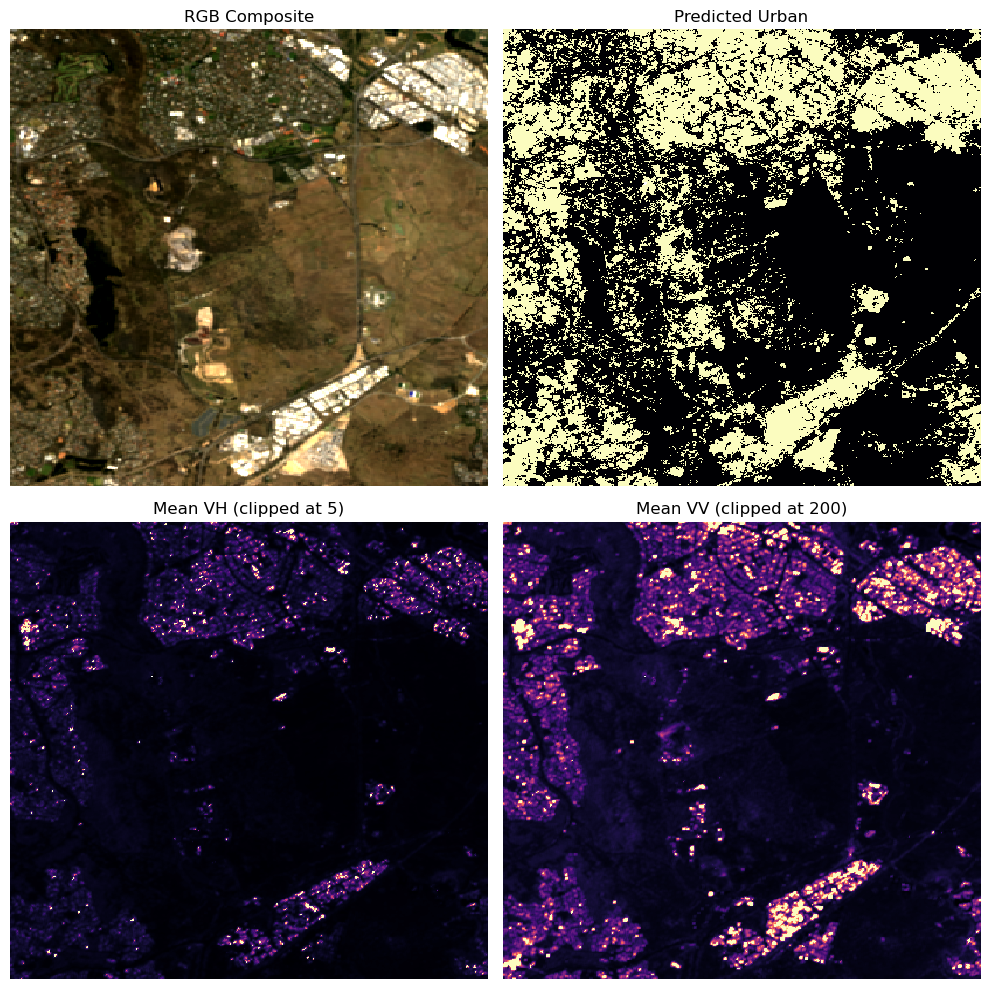

In [133]:
# data to plot
rgb = rgb_test.isel(time=0)[['nbart_red', 'nbart_green', 'nbart_blue']].to_array()
mean_vh_2d = ds_test['mean_vh'].mean(dim='month')
mean_vv_2d = ds_test['mean_vv'].mean(dim='month')

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

rgb = rgb_test.isel(time=0)[['nbart_red', 'nbart_green', 'nbart_blue']].to_array()
rgb.plot.imshow(ax=axes[0, 0], robust=True)
axes[0, 0].set_title('RGB Composite')
axes[0, 0].axis("off")

urban_test.plot.imshow(ax=axes[0, 1], cmap='magma',add_colorbar=False)
axes[0, 1].set_title('Predicted Urban')
axes[0, 1].axis("off")

ds_test['mean_vh'].mean(dim='month').plot.imshow(ax=axes[1, 0], cmap='magma',add_colorbar=False, vamx=.5)
axes[1, 0].set_title('Mean VH')
axes[1, 0].axis("off")

ds_test['mean_vv'].mean(dim='month').plot.imshow(ax=axes[1, 1], cmap='magma',add_colorbar=False, vmax=1)
axes[1, 1].set_title('Mean VV')
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()



In [250]:
# Save to NetCDF
urban_test_wgs84 = urban_test.rio.reproject("EPSG:4326")
urban_test_wgs84.to_netcdf("predicted_urban_wgs84_updated.nc")

mean_vh_2d_wgs84 = mean_vh_2d.rio.reproject("EPSG:4326")
mean_vh_2d_wgs84.to_netcdf("mean_vh_2d_wgs84_updated.nc")

mean_vv_2d_wgs84 = mean_vv_2d.rio.reproject("EPSG:4326")
mean_vv_2d_wgs84.to_netcdf("mean_vv_2d_wgs84_updated.nc")

In [231]:
# convert classificiation to vector
import geopandas as gpd
import rasterio.features
from shapely.geometry import shape

data = urban_test_wgs84.values
transform = urban_test_wgs84.rio.transform()

# get shapes where value == 1, ie urban
shapes = rasterio.features.shapes(data.astype('uint8'), transform=transform)
urban_shapes = [
    {"geometry": shape(geom), "properties": {"value": value}}
    for geom, value in shapes
    if value == 1
]

gdf = gpd.GeoDataFrame.from_features(urban_shapes, crs="EPSG:4326")

gdf.to_file("predicted_urban_updated.geojson", driver="GeoJSON")


/tmp/ipykernel_2754/3079083944.py:11: RuntimeWarning: invalid value encountered in cast
  shapes = rasterio.features.shapes(data.astype('uint8'), transform=transform)


### Compare with current DEA Land Cover

In [ ]:
# load landcover
lc_test = dc.load(
    product=['ga_ls_landcover_class_cyear_3'],
    measurements=['level3'],
    lat=(aoi_bbox.bottom, aoi_bbox.top),
    lon=(aoi_bbox.left, aoi_bbox.right),
    output_crs=output_crs,
    resolution=(30, -30), # NB: res is different from S1
    time=('2024-01-01', '2024-12-31'),
    dask_chunks={},
    skip_broken_datasets=True
)

# urban mask: 1 where landcover is 215 (ie artificial), else 0
urban_mask = (lc_artificial == 215).astype(np.uint8)

In [ ]:
# get some points from new ROI
urban_GUF_box = urban_GUF.odc.reproject(how=lc_test.odc.geobox, resampling='bilinear')
urban = xr.where(urban_GUF_box>70, 1, 0) # consider urban when more than 70% confidence
urban = assign_crs(urban.astype('int16'), crs='EPSG:3577')

np.random.seed(rand_state)
test_points = xr_random_sampling(urban, sampling='manual', manual_class_ratios={'1':100, '0':100})
test_points['class'] = test_points['class'].astype(int)

test_df = pd.DataFrame(columns=cols, index=range(len(test_points)))

for i, (c, g) in enumerate(zip(test_points['class'], test_points.geometry)):
    print(i, end='\r')
    ds_point = ds_final.sel(x=g.x, y=g.y, method="nearest")

    # assign response variable (row i, first column, i.e. column index 0)
    test_df.loc[i,'urban'] = c
    
    for col in test_df.columns[1:]:
        var = '_'.join(col.split('_')[:-1])
        month = int(col.split('_')[-1])

        test_df.loc[i, col] = ds_point.sel(month=month)[var].data

test_df.to_csv('test_samples_updated.csv',index=False)


# split response and explanatory vars
resp_test = test_df['urban'].astype(int).copy() 
expl_test = test_df[predictors].copy()

In [ ]:
# true labels and predictions
y_true = resp_test
y_pred = rf_best.predict(expl_test[predictors])

cm = confusion_matrix(y_true, y_pred)

# show percentages (recall)
cm_normalised = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cm_normalised, annot=True, fmt='.2%', cmap='Blues', cbar=False, ax=ax)
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
ax.set_title('Confusion Matrix **RF Model**')

# add counts in the cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j+0.5, i+0.5, f'{cm[i, j]}\n', 
                ha='center', va='bottom', color='black')

plt.show()

# metrics
accuracy = accuracy_score(y_true, y_pred)
f1_weighted = f1_score(y_true, y_pred, average='weighted')
precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.4f}')
print(f'Weighted F1 Score: {f1_weighted:.4f}')
print(f'Weighted Precision: {precision_weighted:.4f}')
print(f'Weighted Recall: {recall_weighted:.4f}')

In [ ]:

# Extract urban mask values at test points
mask_values = []
for g in test_points.geometry:
    val = urban_mask.sel(x=g.x, y=g.y, method="nearest").data
    mask_values.append(int(val))

mask_values = pd.Series(mask_values, name='urban_mask')

# True labels from your test dataframe
y_true = test_df['urban'].astype(int)
y_pred_mask = mask_values

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_mask)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', cbar=False, ax=ax)
ax.set_xlabel('Urban Mask Prediction')
ax.set_ylabel('True Urban Label')
ax.set_title('Confusion Matrix **DEA Land Cover**')

# Add counts inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.5, f'{cm[i, j]}\n', ha='center', va='bottom', color='black')

plt.show()

# Calculate performance metrics
accuracy = accuracy_score(y_true, y_pred_mask)
f1_weighted = f1_score(y_true, y_pred_mask, average='weighted')
precision_weighted = precision_score(y_true, y_pred_mask, average='weighted')
recall_weighted = recall_score(y_true, y_pred_mask, average='weighted')

print(f'Accuracy: {accuracy:.4f}')
print(f'Weighted F1 Score: {f1_weighted:.4f}')
print(f'Weighted Precision: {precision_weighted:.4f}')
print(f'Weighted Recall: {recall_weighted:.4f}')

### Example screenshots for comparison of models

The semi-transparent layer is the RF model prediction, below is a RGB of a clear day in Feb 2025

![](./image.png)

The semi-transparent layer is the RF model prediction, below is the DEA LC classification

![](./image.png)